In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)
df=sns.load_dataset('tips')
print('Loaded tips dataset:',df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Types of data & variables

In [6]:

print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [9]:
print('Mean total_bill:', round(df['total_bill'].mean(), 2))


print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


LAB EXERCISE-1

1.Numerical vs categorical columns

In [10]:

print("Numerical columns:", df.select_dtypes(include="number").columns.tolist())
print("Categorical columns:", df.select_dtypes(include="object").columns.tolist())



Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: []


2.Mean of a numerical column

In [11]:

print("Mean of tip:", df["tip"].mean())


Mean of tip: 2.99827868852459


3.Value counts of a categorical column

In [12]:

print("Value counts of sex:")
print(df["sex"].value_counts())


Value counts of sex:
sex
Male      157
Female     87
Name: count, dtype: int64


Measures of central tendency

In [16]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode   :', round(col.mode()[0], 2))

Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


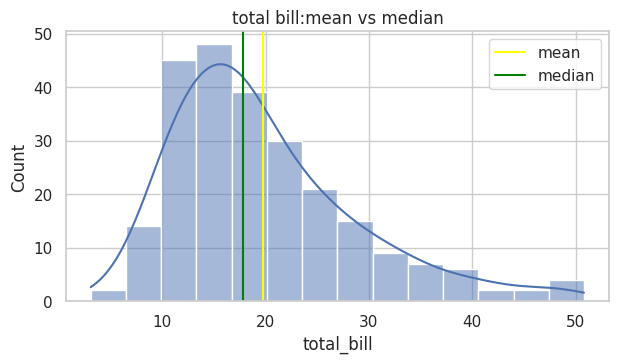

In [18]:
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')
plt.figure(figsize=(7,3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(), color='yellow', label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend();plt.title('total bill:mean vs median'); plt.show()

LAB EXERCISE-2

1.mean.median,mode

In [20]:

col = df['tip']

print('Mean   :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode   :', round(col.mode()[0], 2))


Mean   : 3.0
Median : 2.9
Mode   : 2.0


2.mean>median

In [21]:
col = df['tip']

print('mean > median ?', col.mean() > col.median(), '-> right-skewed')


mean > median ? True -> right-skewed


3.Plot a histogram of tip with vertical lines at the mean and median

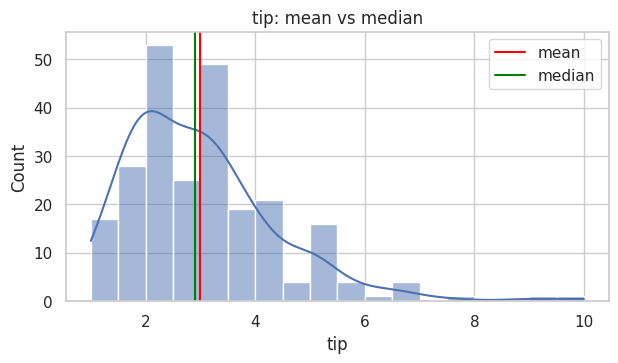

In [22]:
col = df['tip']

plt.figure(figsize=(7, 3.5))

sns.histplot(col, kde=True)

plt.axvline(col.mean(), color='red', label='mean')
plt.axvline(col.median(), color='green', label='median')

plt.legend()
plt.title('tip: mean vs median')
plt.show()


MEASURES OF SPREAD

In [24]:

col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))

Range : 47.74
Var   : 79.25
Std   : 8.9


In [26]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR:', round(iqr,2), '->spread of the middle 50% (robust to outliers)')


Q1 (25%): 13.35
Q3 (75%): 24.13
IQR: 10.78 ->spread of the middle 50% (robust to outliers)


LAB EXERCISE-3

1.Range,variance,std

In [27]:
col = df['tip']

print('Range              :', round(col.max() - col.min(), 2))
print('Variance           :', round(col.var(), 2))
print('Standard Deviation :', round(col.std(), 2))


Range              : 9.0
Variance           : 1.91
Standard Deviation : 1.38


2.Compare Q1,Q3 and the IQR

In [28]:
col = df['tip']

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

print('Q1  :', round(Q1, 2))
print('Q3  :', round(Q3, 2))
print('IQR :', round(IQR, 2))


Q1  : 2.0
Q3  : 3.56
IQR : 1.56


3.Most robust measure of spread

In [ ]:
# IQR is the most robust measure of spread because
# it is less affected by extreme values (outliers).


SHAPE:FIVE-NUMBER SUMMARY AND BOX PLOT

In [31]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


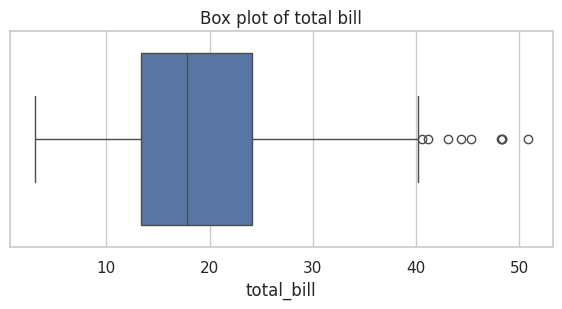

In [33]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total bill');plt.show()

LAB EXERCISE-4

1.five-number summary

In [34]:
col = df['tip']

print('Min :', col.min())
print('25% :', col.quantile(0.25))
print('50% :', col.quantile(0.50))
print('75% :', col.quantile(0.75))
print('Max :', col.max())


Min : 1.0
25% : 2.0
50% : 2.9
75% : 3.5625
Max : 10.0


2.Skewness

In [35]:
col = df['tip']

print('Skewness:', round(col.skew(), 2))



Skewness: 1.47


3.Box plot

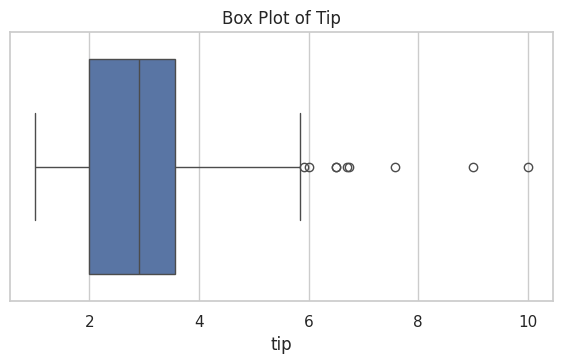

In [36]:
col = df['tip']

plt.figure(figsize=(7, 3.5))
sns.boxplot(x=col)

plt.title('Box Plot of Tip')
plt.show()


CORRELATION AND SUMMARIZING A DATASET

In [37]:
corr = df.corr(numeric_only=True)
print(corr.round(2))
print('\ntotal bill vs tip:',round(corr.loc['total_bill', 'tip'],2), '->strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total bill vs tip: 0.68 ->strong positive


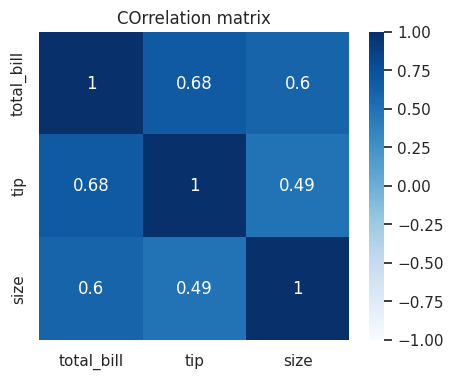

In [38]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('COrrelation matrix');plt.show()

In [39]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


LAB EXERCISE-5

1.Correlation matrix

In [40]:
corr = df.corr(numeric_only=True)

print(corr.round(2))


            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


2.Correlation heatmap

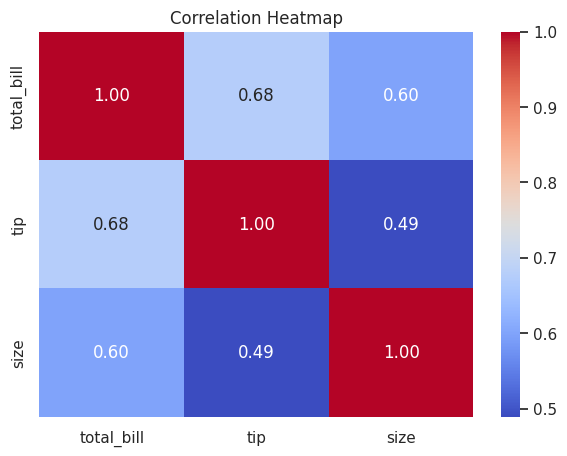

In [41]:
plt.figure(figsize=(7, 5))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()


3.df.describe() and 3 insights

In [43]:
print(df.describe())



       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000
